# Curating samples from the xView 

- sample from promising images
- cross-check with existing annotations
- output for annotating the (missing label) 'road'


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys

import time as tm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from functools import partial

sys.path.append('..')

import src.plotting as splo
import src.data_utils as sdut
import src.geom_utils as sgut

## Set up namespace, e.g. point to data

In [3]:
data_path = '../data/xView-train_images-subset/'
label_path = '../data/xView/labels-0/'

out_path = '../data/xView/images-0/'

In [4]:
def combine_labels( folder, res= 128):
    label_files = os.listdir( folder)
    assert all([f.endswith('.csv') for f in label_files])
    df = pd.DataFrame()
    for file in label_files:
        df_ = pd.read_csv(f'{folder}{file}')
        to_drop = df_.loc[ df_['labels'] == 'reject'].index
        df_.drop( labels= to_drop, inplace= True)
        df_['buildings'] = (df_['built_area'] / (res**2) > 0.25).astype(int)
        df_['cars'] = (df_['n_cars'] + df_['n_bus_trucks'] > 0).astype(int)
        df_['roads'] = df_['roads'].fillna(0).astype(int)
        df_['B_R_C'] = df_.apply( lambda x: f'{x.buildings}{x.roads}{x.cars}', axis= 1)
        print(f'File {file}, keeping {len(df_)} entries.')
        df = pd.concat([df,df_])
    df['bbox_np'] = df['bbox_np'].map( lambda x: [int(y.strip('[]')) for y in x.split(',')])
    df['im_source'] = df.im_name.str.split('for_tiff').map( lambda x: x[0]).str.split('_').map( lambda x: x[0])
    df['image'] = 'tif' + df['im_source'] + '_x' + df['xs'].astype(str) + '_y' + df['ys'].astype(str) + '.png'
    df.loc[ df['labels']=='unlabel',['buildings','roads','cars','B_R_C']] = -1, -1, -1, ''
    df.reset_index( inplace= True, drop= True)
    return df
    

## Investigate data, try things out 

_**you can even add fancy markdown throughout to document things..?**_

In [20]:
df = combine_labels( label_path)
df.shape

File for_tiff102.csv, keeping 411 entries.
File for_tiff1037.csv, keeping 142 entries.
File for_tiff104.csv, keeping 117 entries.
File for_tiff105.csv, keeping 113 entries.
File for_tiff1051.csv, keeping 225 entries.
File for_tiff106.csv, keeping 287 entries.
File for_tiff1063.csv, keeping 169 entries.
File for_tiff1065.csv, keeping 104 entries.
File for_tiff107.csv, keeping 249 entries.
File for_tiff109.csv, keeping 351 entries.
File for_tiff110.csv, keeping 147 entries.
File for_tiff1121.csv, keeping 315 entries.
File for_tiff1124.csv, keeping 228 entries.
File for_tiff1132.csv, keeping 145 entries.


(3003, 14)

In [21]:
df_ = df.loc[ df['labels'] != 'unlabel']
df_.shape

(2293, 14)

<Axes: xlabel='B_R_C'>

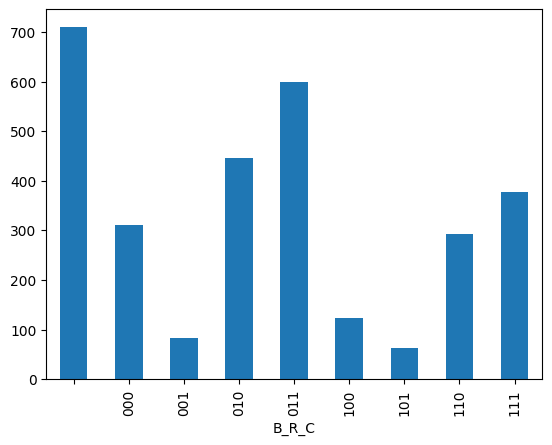

In [43]:
df.groupby('B_R_C').count()['xs'].plot(kind='bar')

Now that we have some high-level understanding can choose poss interesting images

In [44]:
df['im_source'] = df.im_name.str.split('for_tiff').map( lambda x: x[0]).str.split('_').map( lambda x: x[0])
df['image'] = 'tif' + df['im_source'] + '_x' + df['xs'].astype(str) + '_y' + df['ys'].astype(str) + '.png'

In [41]:
df.loc[ df['labels']=='unlabel',['buildings','roads','cars','B_R_C']] = -1, -1, -1, ''

In [45]:
df

,xs,ys,bbox_np,bbox_context,bbox_in_context,built_area,n_cars,n_bus_trucks,roads,im_name,labels,buildings,cars,B_R_C,im_source,image
0,65,1613,"[1, 1549, 129, 1677]","[0, 1485, 256, 1741]","[1, 64, 129, 192]",22088.000000,0.0,0.0,-1,102_0.png,unlabel,-1,-1,,102,tif102_x65_y1613.png
1,66,1445,"[2, 1381, 130, 1509]","[0, 1317, 256, 1573]","[2, 64, 130, 192]",3416.000000,0.0,0.0,-1,102_1.png,unlabel,-1,-1,,102,tif102_x66_y1445.png
2,67,370,"[3, 306, 131, 434]","[0, 242, 256, 498]","[3, 64, 131, 192]",9246.000000,1.0,0.0,-1,102_2.png,unlabel,-1,-1,,102,tif102_x67_y370.png
3,67,1496,"[3, 1432, 131, 1560]","[0, 1368, 256, 1624]","[3, 64, 131, 192]",8321.000000,1.0,0.0,-1,102_3.png,unlabel,-1,-1,,102,tif102_x67_y1496.png
4,79,648,"[15, 584, 143, 712]","[0, 520, 256, 776]","[15, 64, 143, 192]",14542.000000,0.0,0.0,1,102_5.png,road,1,0,110,102,tif102_x79_y648.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2998,2781,2481,"[2717, 2417, 2845, 2545]","[2653, 2353, 2909, 2609]","[64, 64, 192, 192]",0.659241,0.0,3.0,1,1132_280.png,road,0,1,011,1132,tif1132_x2781_y2481.png
2999,2865,556,"[2801, 492, 2929, 620]","[2737, 428, 2993, 684]","[64, 64, 192, 192]",0.361450,0.0,0.0,-1,1132_285.png,unlabel,-1,-1,,1132,tif1132_x2865_y556.png
3000,2899,965,"[2835, 901, 2963, 1029]","[2761, 837, 3017, 1093]","[74, 64, 202, 192]",0.184509,0.0,0.0,1,1132_287.png,road,0,0,010,1132,tif1132_x2899_y965.png
3001,2900,3410,"[2836, 3346, 2964, 3474]","[2761, 3282, 3017, 3538]","[75, 64, 203, 192]",1.030945,1.0,0.0,1,1132_288.png,road,0,1,011,1132,tif1132_x2900_y3410.png


In [49]:
im_src_loaded = None
for bbox_, name_, im_src_ in zip(df['bbox_np'][:3], df['image'][:3], df['im_source'][:3]):
    if im_src_loaded != im_src_:
        im_src_loaded = f'{data_path}{im_src_}.tif'
        image_ = np.array( Image.open( im_src_loaded))
    
    Image.fromarray( sgut.crop_to_bbox( image_, bbox_)).save( f'{out_path}{name_}')